In [9]:
import os
import sys
sys.path.append('/home/royhirsch/conformal')

from ml_collections import config_dict
import logging
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F


from data import get_dataloaders
from trainer import Trainer, get_optimizer, get_scheduler
import utils as utils
from experiment import get_config, run_experiment

config = get_config()
config.alpha = 0.1
config.lr = 5e-4
config.wd = 1e-6
config.conformal_module_name = 'aps'
config.use_score_clipping = False
config.criteria_name = 'cqr'
config.num_epochs = 100
config.drop_rate = 0.0
config.hidden_dim = 256

utils.seed_everything(config.seed)
utils.create_logger(config.exp_dir, False)
outs = run_experiment(config)

INFO - 09/05/23 06:26:53 - 0:00:00 - Created main log at /home/royhirsch/conformal/exps/temp1/net_launcher_log.log
INFO - 09/05/23 06:26:54 - 0:00:00 - Split 47280 samples to train/val/test : 40000/6000/500
INFO - 09/05/23 06:26:54 - 0:00:00 - train shape: (40000,)
INFO - 09/05/23 06:26:54 - 0:00:00 - valid shape: (6000,)
INFO - 09/05/23 06:26:54 - 0:00:00 - test shape: (500,)
  2%|▏         | 2/100 [00:01<01:33,  1.05it/s]
INFO - 09/05/23 06:26:56 - 0:00:02 - Temp is 1.2211
INFO - 09/05/23 06:26:57 - 0:00:03 - Baseline mets: set_size_mean: 4.492 | set_size_std: 1.833 | acc_per_label_mean: 0.989 | acc_per_label_max: 0.997 | acc_per_label_min: 0.980 | acc: 0.993 | qhat: 0.986
INFO - 09/05/23 06:26:57 - 0:00:03 - NN(
                                       (layers): Sequential(
                                         (0): Linear(in_features=2048, out_features=256, bias=True)
                                         (1): ReLU()
                                         (2): Linear(in_featu

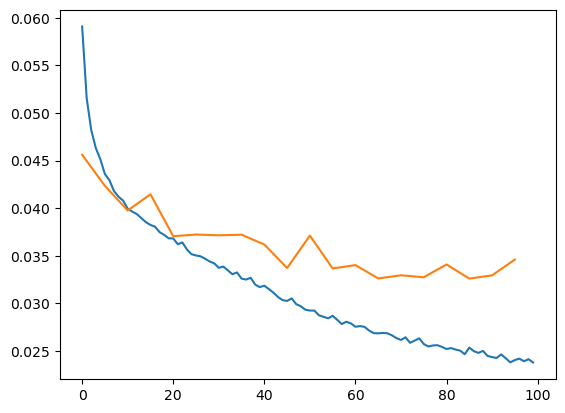

In [6]:
import matplotlib.pyplot as plt
plt.plot(outs['history']['loss'], label='loss')
plt.plot(np.arange(0, len(outs['history']['loss']), config.val_interval),
         outs['history']['val_loss'], label='val_loss')

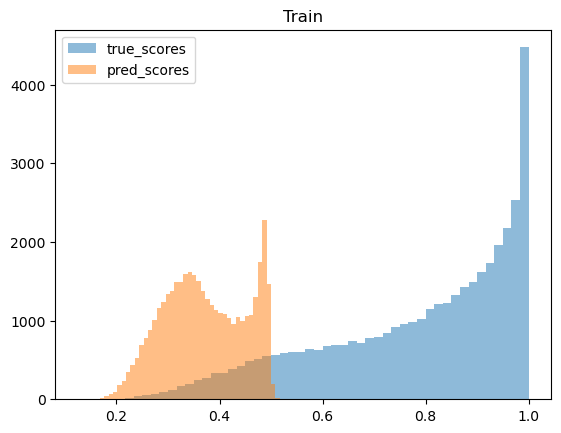

In [10]:
nbins = 50
pred_scores = outs['train_out']['pred_scores']
true_scores = outs['train_out']['true_scores']

plt.title('Train')
plt.hist(true_scores, bins=nbins, label='true_scores', alpha=0.5)
plt.hist(pred_scores, bins=nbins, label='pred_scores', alpha=0.5)
plt.legend()

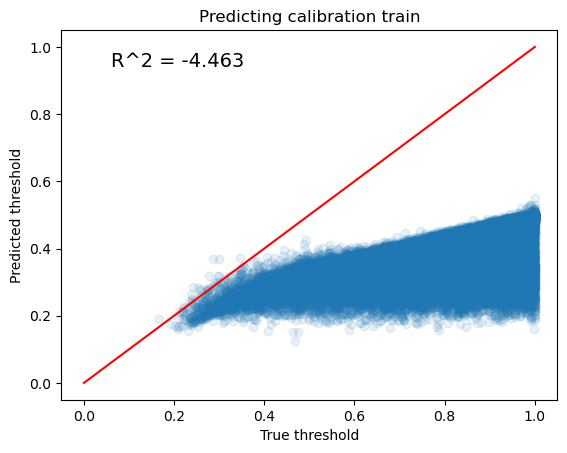

In [11]:
# outputs = val_outputs
outputs = outs['train_out']
plt.scatter(outputs['true_scores'], outputs['pred_scores'], alpha = 0.1)
plt.plot([0,1], [0,1], color="red")
plt.xlabel("True threshold")
plt.ylabel("Predicted threshold")

r2 = utils.calc_r2(outputs['true_scores'], outputs['pred_scores'])

plt.text(0.1, 0.9, f"R^2 = {r2:.3f}", transform=plt.gca().transAxes, fontsize=14)
plt.title("Predicting calibration train")
plt.show()

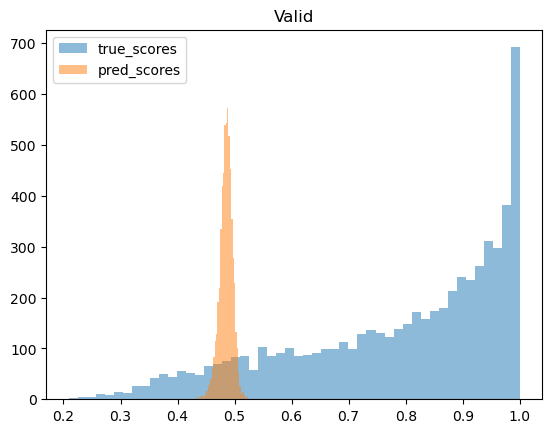

In [6]:
nbins = 50
pred_scores = outs['val_out']['pred_scores']
true_scores = outs['val_out']['true_scores']

plt.title('Valid')
plt.hist(true_scores, bins=nbins, label='true_scores', alpha=0.5)
plt.hist(pred_scores, bins=nbins, label='pred_scores', alpha=0.5)
plt.legend()

In [8]:
# calibrate with the test set

# get the predicted scores from the trained model
pred_scores = outs['test_out']['pred_scores']
true_scores = outs['test_out']['true_scores']
if config.use_score_clipping:
    clip_value = max(true_scores)
    pred_scores[pred_scores > clip_value] = clip_value

# calculate the diff and the alpha quantile
diff = true_scores - pred_scores
alpha = config.alpha
n = len(diff)
qhat = np.quantile(
    diff, np.ceil((n + 1) * (1 - alpha)) / n, interpolation="higher")
print(qhat)

# update the validation scores
pred_scores = outs['val_out']['pred_scores']
true_scores = outs['val_out']['true_scores']
cls_probs = outs['val_out']['cls_probs']
cls_labels = outs['val_out']['cls_labels']

if config.use_score_clipping:
    pred_scores[pred_scores > clip_value] = clip_value

modified_scores = pred_scores + qhat
inds = np.where(modified_scores >= 1.)
if len(inds[0]):
    print(len(inds[0]) / len(cls_labels))
    modified_scores[inds[0]] = 1 - config.alpha

from conformal import get_conformal_module

conformal_module = get_conformal_module(config.conformal_module_name)
if config.use_score_clipping:
    conformal_module.set_score_clipping(clip_value)
sets = conformal_module.get_sets(modified_scores, cls_probs)
mets = conformal_module.get_conformal_mets(sets, cls_labels)
print(mets)


0.48899123
0.007666666666666666
{'set_size_mean': 3.908166666666667, 'set_size_std': 1.5878916752166132, 'acc_per_label_mean': 0.9721441518756482, 'acc_per_label_max': 0.9957953749124037, 'acc_per_label_min': 0.9216417910447762, 'acc': 0.9836666666666667}


/tmp/ipykernel_41328/3238130136.py:14: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  qhat = np.quantile(


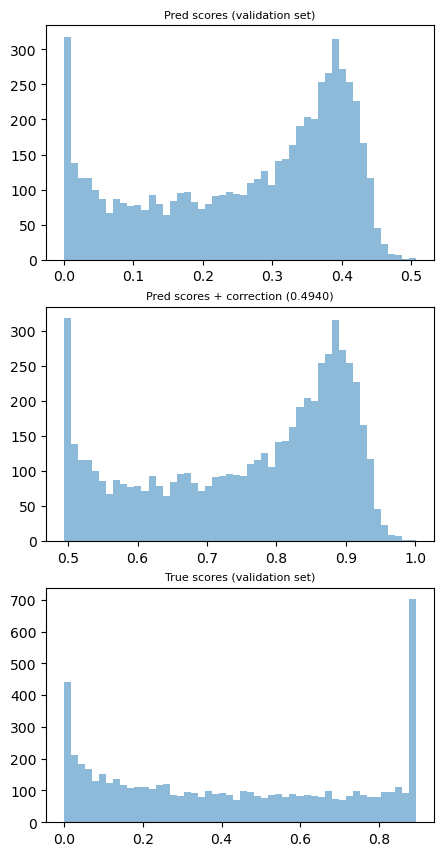

In [7]:
nbins = 50
fontsize = 8
plt.figure(figsize=(5,14))

plt.subplot(4,1,1)
_ = plt.hist(pred_scores, label='pred', alpha=0.5, bins=nbins)
plt.title('Pred scores (validation set)', fontsize=fontsize)

plt.subplot(4,1,2)
_ = plt.hist(pred_scores + qhat, label='pred_scores + qhat', alpha=0.5, bins=nbins)
plt.title(f'Pred scores + correction ({qhat:.4f})', fontsize=fontsize)

plt.subplot(4,1,3)
_ = plt.hist(true_scores, label='true_scores', alpha=0.5, bins=nbins)
plt.title('True scores (validation set)', fontsize=fontsize)

# plt.subplot(1,4,)
# _ = plt.hist(modified_scores, label='modified_scores', alpha=0.5, bins=nbins)

plt.show()